In [1]:
# IMPORTS & SETUP
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    classification_report, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Tạo thư mục lưu hình ảnh cho báo cáo
os.makedirs('figures', exist_ok=True)

# Thiết lập thiết bị tính toán (GPU nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# LOAD AND PROCESS DATA
def load_and_process_data(filepath):
    print("Đang xử lý dữ liệu...")
    df = pd.read_csv(filepath)

    # 1. Xử lý missing values
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(0)

    # 2. Xử lý nhãn (Churn)
    if 'Churn' in df.columns:
        df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

    # 3. Mã hóa One-Hot
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    if 'customerID' in categorical_cols:
        categorical_cols.remove('customerID')
        df = df.drop('customerID', axis=1)

    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # 4. Tách Features và Labels
    X = df_encoded.drop('Churn', axis=1).values
    y = df_encoded['Churn'].values

    # 5. Chia tập Train/Test (Stratified để giữ nguyên tỷ lệ lớp)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 6. Chuẩn hóa Z-Score (Cực kỳ quan trọng cho Gaussian-Bernoulli RBM)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 7. Chuyển đổi sang PyTorch Tensors
    X_train_pt = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_pt = torch.tensor(y_train, dtype=torch.long)
    X_test_pt = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_pt = torch.tensor(y_test, dtype=torch.long)

    print(f"Kích thước tập Train: {X_train_pt.shape}")
    print(f"Kích thước tập Test: {X_test_pt.shape}")

    return X_train_pt, y_train_pt, X_test_pt, y_test_pt

# Chạy hàm tải dữ liệu
try:
    X_train, y_train, X_test, y_test = load_and_process_data('data.csv')
except FileNotFoundError:
    print("Không tìm thấy file 'data.csv'.")

Đang xử lý dữ liệu...
Kích thước tập Train: torch.Size([5634, 30])
Kích thước tập Test: torch.Size([1409, 30])


In [3]:
# RBM CLASS DEFINITION
class RBM(nn.Module):
    def __init__(self, n_visible, n_hidden, k=1):
        super(RBM, self).__init__()
        self.W = nn.Parameter(torch.randn(n_visible, n_hidden) * 0.01)
        self.v_bias = nn.Parameter(torch.zeros(n_visible))
        self.h_bias = nn.Parameter(torch.zeros(n_hidden))
        self.k = k  # Số bước Gibbs Sampling (CD-k)

    def sample_h_given_v(self, v):
        activation = torch.matmul(v, self.W) + self.h_bias
        p_h_given_v = torch.sigmoid(activation)
        h_sampled = torch.bernoulli(p_h_given_v)
        return p_h_given_v, h_sampled

    def sample_v_given_h(self, h):
        mean = torch.matmul(h, self.W.t()) + self.v_bias
        # Gaussian Visible Units (phù hợp với dữ liệu đã chuẩn hóa Z-score)
        return mean + torch.randn_like(mean)

    def free_energy(self, v):
        # Tính Free Energy - Dùng làm Unsupervised Anomaly Score
        v_term = 0.5 * torch.sum((v - self.v_bias) ** 2, dim=1)
        wx_b = torch.matmul(v, self.W) + self.h_bias
        h_term = torch.sum(F.softplus(wx_b), dim=1)
        return v_term - h_term

    def cd(self, v0, lr=0.01):
        # Thuật toán Contrastive Divergence (CD-1)
        p_h0, h0 = self.sample_h_given_v(v0)

        hk = h0
        vk = v0
        for _ in range(self.k):
            vk = self.sample_v_given_h(hk)
            p_hk, hk = self.sample_h_given_v(vk)

        batch_size = v0.size(0)
        positive_grad = torch.matmul(v0.t(), p_h0)
        negative_grad = torch.matmul(vk.t(), p_hk)

        # Cập nhật trọng số
        with torch.no_grad():
            self.W += lr * (positive_grad - negative_grad) / batch_size
            self.v_bias += lr * torch.mean(v0 - vk, dim=0)
            self.h_bias += lr * torch.mean(p_h0 - p_hk, dim=0)

        return F.mse_loss(v0, vk).item()

    def forward(self, v):
        # Tính xác suất lớp ẩn để đẩy lên lớp tiếp theo
        p_h, _ = self.sample_h_given_v(v)
        return p_h

In [4]:
# DBN CLASS DEFINITION
class DBN(nn.Module):
    def __init__(self, layer_sizes):
        super(DBN, self).__init__()
        self.rbms = nn.ModuleList()
        # Xây dựng các lớp RBM xếp chồng
        for i in range(len(layer_sizes) - 1):
            self.rbms.append(RBM(layer_sizes[i], layer_sizes[i+1]))

        # Lớp Classifier cuối cùng (Sử dụng LogSoftmax cho NLLLoss)
        self.classifier = nn.Sequential(
            nn.Linear(layer_sizes[-1], 2),
            nn.LogSoftmax(dim=1)
        )

    def greedy_pretrain(self, train_tensor, batch_size, epochs_per_layer=15, lr=0.01):
        print("\n>>> Bắt đầu Unsupervised Pre-training...")
        current_data = train_tensor
        history_loss = []

        for i, rbm in enumerate(self.rbms):
            print(f"--- Training RBM Layer {i+1} ---")
            dataset = TensorDataset(current_data)
            loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
            layer_loss = []

            for epoch in range(epochs_per_layer):
                epoch_error = 0
                for batch in loader:
                    v = batch[0].to(device)
                    epoch_error += rbm.cd(v, lr)

                avg_err = epoch_error / len(loader)
                layer_loss.append(avg_err)
                if (epoch+1) % 5 == 0:
                    print(f"Epoch {epoch+1}/{epochs_per_layer}, MSE: {avg_err:.4f}")

            history_loss.append(layer_loss)

            # Truyền dữ liệu qua RBM hiện tại để tạo input cho RBM tiếp theo
            if i < len(self.rbms) - 1:
                new_data_list = []
                with torch.no_grad():
                    for batch in loader:
                        v = batch[0].to(device)
                        prob_h = rbm.forward(v)
                        new_data_list.append(prob_h.cpu())
                current_data = torch.cat(new_data_list, dim=0)

        return history_loss

    def forward(self, x):
        out = x
        for rbm in self.rbms:
            out = rbm.forward(out)
        return self.classifier(out)

In [5]:
# MODEL INITIALIZATION & UNSUPERVISED PRE-TRAINING
input_dim = X_train.shape[1]
# Kiến trúc: Input -> 64 (RBM 1) -> 32 (RBM 2) -> 2 (Classifier)
dbn = DBN([input_dim, 64, 32]).to(device)

# Huấn luyện Generative Model
pretrain_history = dbn.greedy_pretrain(
    X_train,
    batch_size=64,
    epochs_per_layer=100,
    lr=0.01
)


>>> Bắt đầu Unsupervised Pre-training...
--- Training RBM Layer 1 ---
Epoch 5/100, MSE: 1.6753
Epoch 10/100, MSE: 1.5639
Epoch 15/100, MSE: 1.5516
Epoch 20/100, MSE: 1.5393
Epoch 25/100, MSE: 1.5333
Epoch 30/100, MSE: 1.5260
Epoch 35/100, MSE: 1.5166
Epoch 40/100, MSE: 1.5119
Epoch 45/100, MSE: 1.5120
Epoch 50/100, MSE: 1.4990
Epoch 55/100, MSE: 1.4964
Epoch 60/100, MSE: 1.4843
Epoch 65/100, MSE: 1.4827
Epoch 70/100, MSE: 1.4788
Epoch 75/100, MSE: 1.4783
Epoch 80/100, MSE: 1.4790
Epoch 85/100, MSE: 1.4804
Epoch 90/100, MSE: 1.4752
Epoch 95/100, MSE: 1.4767
Epoch 100/100, MSE: 1.4605
--- Training RBM Layer 2 ---
Epoch 5/100, MSE: 1.0467
Epoch 10/100, MSE: 1.0410
Epoch 15/100, MSE: 1.0374
Epoch 20/100, MSE: 1.0405
Epoch 25/100, MSE: 1.0402
Epoch 30/100, MSE: 1.0388
Epoch 35/100, MSE: 1.0359
Epoch 40/100, MSE: 1.0433
Epoch 45/100, MSE: 1.0386
Epoch 50/100, MSE: 1.0320
Epoch 55/100, MSE: 1.0409
Epoch 60/100, MSE: 1.0336
Epoch 65/100, MSE: 1.0318
Epoch 70/100, MSE: 1.0350
Epoch 75/100, MSE

In [6]:
# SUPERVISED FINE-TUNING (WITH CLASS WEIGHTS)
print("\n>>> Bắt đầu Supervised Fine-tuning...")
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
optimizer = optim.Adam(dbn.parameters(), lr=0.001)

# TÍNH TOÁN CLASS WEIGHTS CHO TẬP TRAIN
churn_count = (y_train == 1).sum().item()
non_churn_count = (y_train == 0).sum().item()
total_samples = len(y_train)

# Trọng số tỷ lệ nghịch với số lượng mẫu
weight_0 = total_samples / (2.0 * non_churn_count)
weight_1 = total_samples / (2.0 * churn_count)
class_weights = torch.tensor([weight_0, weight_1], dtype=torch.float32).to(device)

print(f"Trọng số áp dụng: Non-Churn={weight_0:.2f}, Churn={weight_1:.2f}")

# Khởi tạo hàm Loss với trọng số
criterion = nn.NLLLoss(weight=class_weights)

fine_tune_loss_history = []
accuracy_history = []
epochs = 100

for epoch in range(epochs):
    dbn.train()
    total_loss, correct, total = 0, 0, 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = dbn(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)

    avg_loss = total_loss / len(train_loader)
    acc = 100. * correct / total
    fine_tune_loss_history.append(avg_loss)
    accuracy_history.append(acc)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}: Loss={avg_loss:.4f}, Accuracy={acc:.2f}%")

print("Hoàn tất huấn luyện!")


>>> Bắt đầu Supervised Fine-tuning...
Trọng số áp dụng: Non-Churn=0.68, Churn=1.88
Epoch 5/100: Loss=0.4910, Accuracy=74.30%
Epoch 10/100: Loss=0.4854, Accuracy=75.03%
Epoch 15/100: Loss=0.4855, Accuracy=74.97%
Epoch 20/100: Loss=0.4881, Accuracy=74.96%
Epoch 25/100: Loss=0.4820, Accuracy=75.75%
Epoch 30/100: Loss=0.4816, Accuracy=75.10%
Epoch 35/100: Loss=0.4821, Accuracy=76.11%
Epoch 40/100: Loss=0.4763, Accuracy=75.99%
Epoch 45/100: Loss=0.4816, Accuracy=76.23%
Epoch 50/100: Loss=0.4763, Accuracy=76.04%
Epoch 55/100: Loss=0.4784, Accuracy=76.29%
Epoch 60/100: Loss=0.4715, Accuracy=76.59%
Epoch 65/100: Loss=0.4690, Accuracy=76.16%
Epoch 70/100: Loss=0.4711, Accuracy=76.57%
Epoch 75/100: Loss=0.4711, Accuracy=76.34%
Epoch 80/100: Loss=0.4685, Accuracy=76.25%
Epoch 85/100: Loss=0.4687, Accuracy=76.45%
Epoch 90/100: Loss=0.4738, Accuracy=76.48%
Epoch 95/100: Loss=0.4623, Accuracy=76.71%
Epoch 100/100: Loss=0.4634, Accuracy=77.46%
Hoàn tất huấn luyện!



SUPERVISED MODEL PERFORMANCE
AUC: 0.8403
Accuracy: 0.7324
Recall (Churn=1): 0.8048

              precision    recall  f1-score   support

           0     0.9092    0.7063    0.7950      1035
           1     0.4975    0.8048    0.6149       374

    accuracy                         0.7324      1409
   macro avg     0.7034    0.7555    0.7050      1409
weighted avg     0.7999    0.7324    0.7472      1409

UNSUPERVISED FREE ENERGY PERFORMANCE
Free Energy AUC: 0.4410


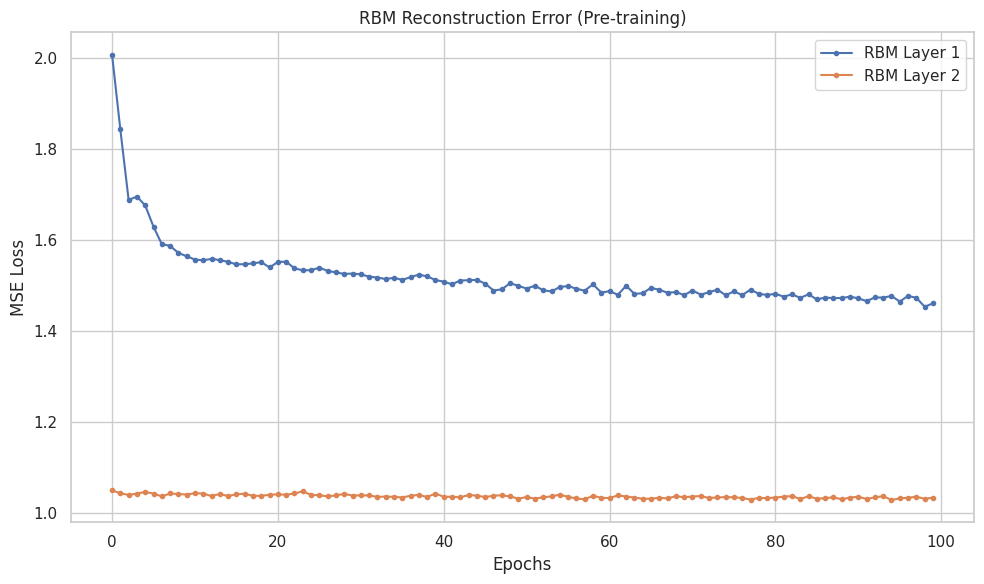

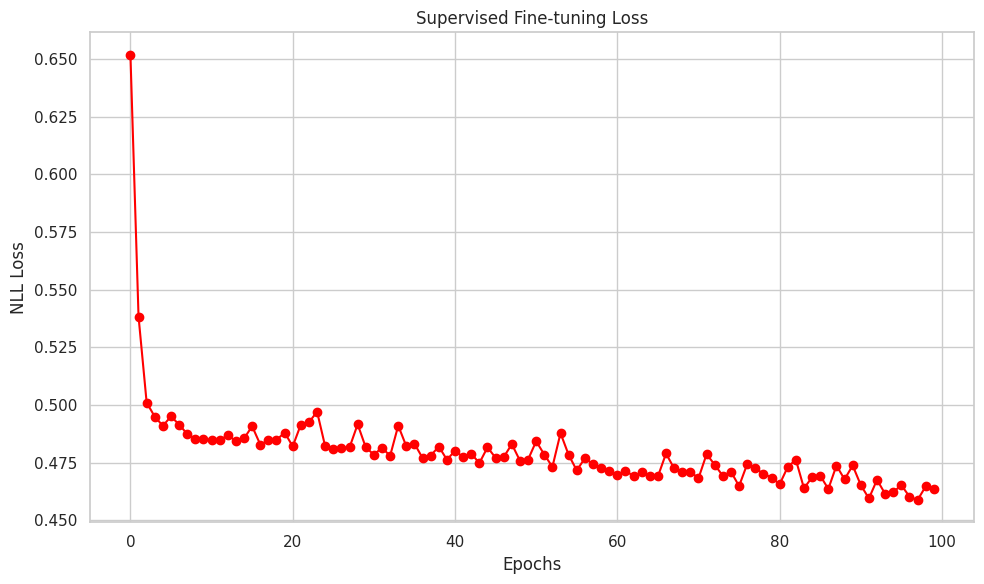

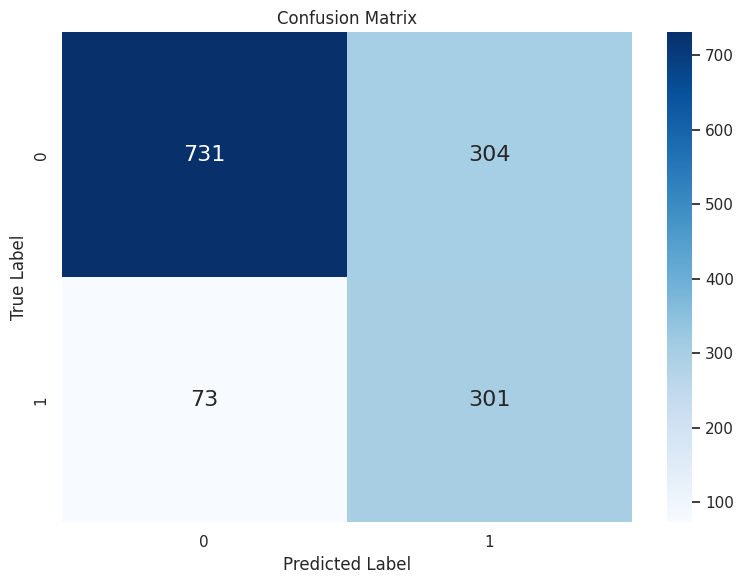

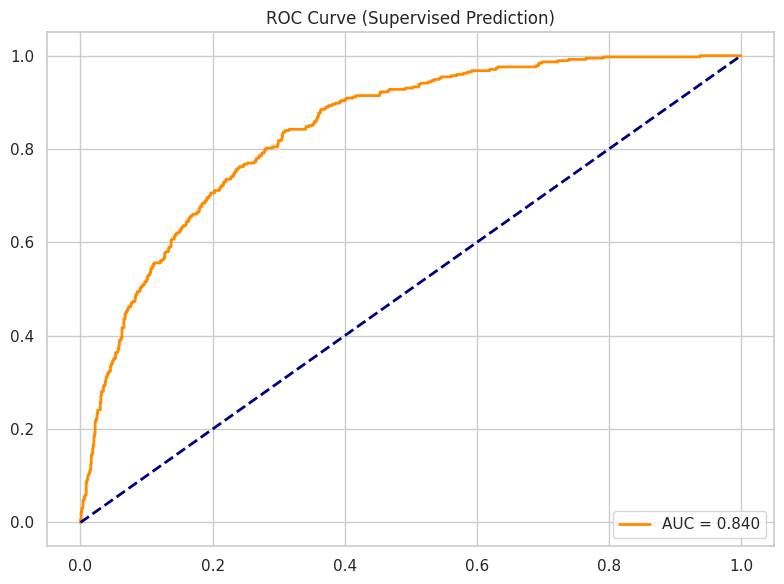

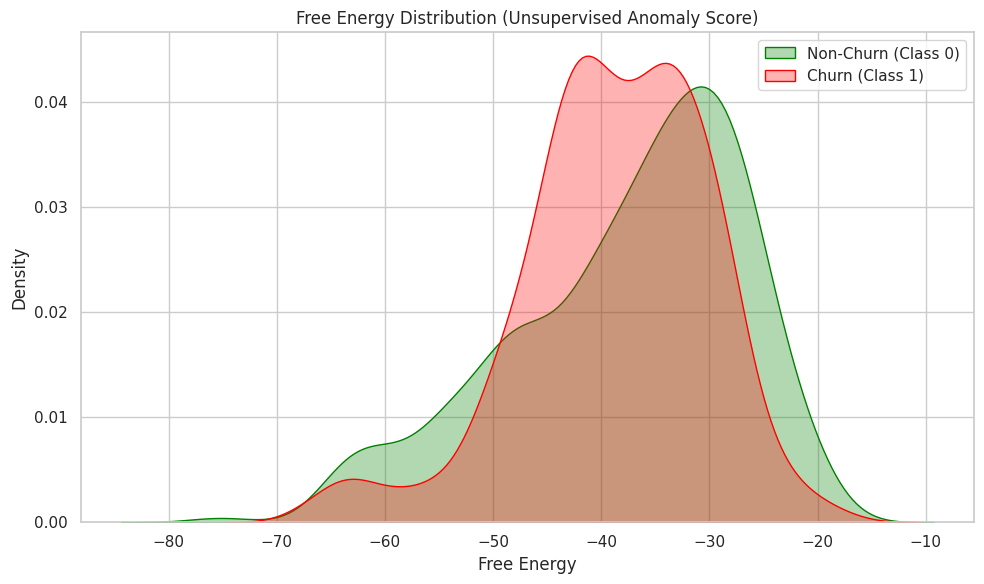


>>> Đã lưu tất cả biểu đồ vào thư mục 'figures/'.


In [7]:
# EVALUATION & VISUALIZATION
dbn.eval()
with torch.no_grad():
    X_test_dev = X_test.to(device)
    output = dbn(X_test_dev)

    # Do dùng LogSoftmax, cần dùng exp để chuyển về xác suất 0-1
    probabilities = torch.exp(output)
    y_probs_positive = probabilities[:, 1].cpu().numpy()
    y_pred = output.argmax(dim=1).cpu().numpy()

    # Tính Free Energy cho tập test
    first_rbm = dbn.rbms[0]
    fe_values = first_rbm.free_energy(X_test_dev).cpu().numpy()

y_true = y_test.cpu().numpy()

# 1. ĐÁNH GIÁ SUPERVISED MODEL
print("\n" + "="*50)
print("SUPERVISED MODEL PERFORMANCE")
print("="*50)
roc_auc = auc(*roc_curve(y_true, y_probs_positive)[:2])
accuracy = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
recall_churn = cm[1,1] / (cm[1,0] + cm[1,1]) if cm.shape == (2,2) else 0

print(f"AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Recall (Churn=1): {recall_churn:.4f}\n")
print(classification_report(y_true, y_pred, digits=4))

# 2. ĐÁNH GIÁ UNSUPERVISED SCORE (FREE ENERGY)
print("="*50)
print("UNSUPERVISED FREE ENERGY PERFORMANCE")
print("="*50)
fpr_fe, tpr_fe, _ = roc_curve(y_true, fe_values)
free_energy_auc = auc(fpr_fe, tpr_fe)
print(f"Free Energy AUC: {free_energy_auc:.4f}")
print("="*50)

# 3. VẼ BIỂU ĐỒ (LƯU VÀO THƯ MỤC 'figures')
sns.set_theme(style="whitegrid")

# Hình 1: RBM Reconstruction Error
plt.figure(figsize=(10, 6))
for i, errors in enumerate(pretrain_history):
    plt.plot(errors, label=f'RBM Layer {i+1}', marker='.')
plt.title("RBM Reconstruction Error (Pre-training)")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.savefig('figures/rbm_reconstruction.png', dpi=300)
plt.show()

# Hình 2: Fine-tuning Loss
plt.figure(figsize=(10, 6))
plt.plot(fine_tune_loss_history, color='red', marker='o')
plt.title("Supervised Fine-tuning Loss")
plt.xlabel("Epochs")
plt.ylabel("NLL Loss")
plt.tight_layout()
plt.savefig('figures/finetune_loss.png', dpi=300)
plt.show()

# Hình 3: Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=300)
plt.show()

# Hình 4: ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_true, y_probs_positive)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve (Supervised Prediction)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('figures/roc_curve.png', dpi=300)
plt.show()

# Hình 5: Free Energy Distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(fe_values[y_true == 0], color="green", label="Non-Churn (Class 0)", fill=True, alpha=0.3)
sns.kdeplot(fe_values[y_true == 1], color="red", label="Churn (Class 1)", fill=True, alpha=0.3)
plt.title("Free Energy Distribution (Unsupervised Anomaly Score)")
plt.xlabel("Free Energy")
plt.legend()
plt.tight_layout()
plt.savefig('figures/free_energy.png', dpi=300)
plt.show()

print("\n>>> Đã lưu tất cả biểu đồ vào thư mục 'figures/'.")